# Notebook 3 — Series de tiempo, correlación pasajeros-casos y proyección de riesgo

## Contexto

Si el flujo de visitantes internacionales es un vector de importación del
sarampión, deberíamos observar que **los picos de pasajeros preceden a los
picos de casos** por algunas semanas. A este desfase temporal se le llama
**lag** y es fundamental para el modelo predictivo: si el lag es de 1-2 meses,
podemos usar el flujo de pasajeros de un mes como feature para predecir
brotes en el mes siguiente.

Este notebook responde tres preguntas:

1. **¿Existe correlación entre flujo de pasajeros internacionales y casos EFES?**
2. **¿En qué lag (desfase) es máxima esa correlación?**
3. **¿Qué nivel de riesgo proyecta el Mundial 2026 para cada ciudad sede?**

### Inputs de notebooks anteriores
| Archivo | Origen |
|---|---|
| `efes_mensual_sedes_target.csv` | Notebook 2 — serie mensual con labels de brote |
| `paises_cluster_riesgo.csv` | Notebook 1 — score de riesgo por país |
| AICM, vuelos, terminal | Cargados en sección 1.4 del Notebook 1 |

In [ ]:
import os

for path in [
    'content/data/raw',
    'content/data/processed',
    'content/reports',
    'content/reports/figures',
    'content/models'
]:
    os.makedirs(path, exist_ok=True)

print("Estructura de carpetas verificada ✅")

Estructura de carpetas verificada ✅


In [ ]:
import os
import shutil

# Define the source and destination directories
source_dir = '/content/'
dest_dir = '../content/content/data/raw'

# Create the destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# List all files in the source directory
files_in_source = os.listdir(source_dir)

print(f"Moving files to: {dest_dir}")

# Iterate through the files and move CSV/XLSX to the destination
for filename in files_in_source:
    if filename.endswith('.csv') or filename.endswith('.xlsx'):
        source_path = os.path.join(source_dir, filename)
        dest_path = os.path.join(dest_dir, filename)
        try:
            shutil.move(source_path, dest_path)
            print(f"Moved: {filename}")
        except Exception as e:
            print(f"Error moving {filename}: {e}")

print("File transfer complete.")

Moving files to: ../content/content/data/raw
File transfer complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.signal import correlate

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_RAW       = 'content/data/raw/'
DATA_PROCESSED = 'content/data/processed/'
OUTPUT_FIGURES = 'content/reports/figures/'

SEDES = {9: 'CDMX', 14: 'Jalisco (Gdl)', 19: 'Nuevo León (Mty)'}
COLORES = {'CDMX': '#4e8ec4', 'Jalisco (Gdl)': '#d4a200', 'Nuevo León (Mty)': '#55a855'}

print('Librerías importadas.')

Librerías importadas.


---
## 1. Carga de datos

Cargamos los tres inputs principales y los llevamos a un formato mensual
unificado con `fecha` como índice temporal.

In [ ]:
# Output del Notebook 2
efes_monthly = pd.read_csv(DATA_PROCESSED + 'efes_mensual_sedes_target.csv')
efes_monthly['anio_mes_dt'] = pd.to_datetime(efes_monthly['anio_mes_dt'])
efes_monthly['anio_mes']    = pd.to_datetime(efes_monthly['anio_mes_dt']).dt.to_period('M')

print(f'EFES mensual: {efes_monthly["anio_mes_dt"].min().date()} → {efes_monthly["anio_mes_dt"].max().date()}')
print(f'Columnas: {list(efes_monthly.columns)}')
efes_monthly.head(3)

EFES mensual: 2020-01-01 → 2025-12-01
Columnas: ['anio_mes', 'anio_mes_dt', 'ENTIDAD_RES', 'sede', 'casos_confirmados', 'casos_sospechosos', 'total_registros', 'tasa_confirmacion', 'vacunados', 'con_complicaciones', 'anomalia_if', 'if_score', 'anomalia_db', 'db_label', 'brote', 'brote_estricto']


,anio_mes,anio_mes_dt,ENTIDAD_RES,sede,casos_confirmados,casos_sospechosos,total_registros,tasa_confirmacion,vacunados,con_complicaciones,anomalia_if,if_score,anomalia_db,db_label,brote,brote_estricto
0,2020-01,2020-01-01,9,CDMX,0,10,10,0.0000,3,0,False,-0.340031,False,0,0,0
1,2020-02,2020-02-01,9,CDMX,0,9,9,0.0000,5,0,False,-0.339314,False,0,0,0
2,2020-03,2020-03-01,9,CDMX,75,176,251,0.2988,93,9,True,-0.784772,True,-1,1,1


In [ ]:
MES_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def mes_a_fecha(df, col_anio='anio', col_mes='mes'):
    df = df.copy()
    df['mes_num'] = df[col_mes].str.lower().map(MES_MAP)
    df['fecha']   = pd.to_datetime(
        df[[col_anio, 'mes_num']].rename(columns={col_anio:'year','mes_num':'month'}).assign(day=1)
    )
    return df

# AICM mensual
aicm = mes_a_fecha(pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_de_AICM.csv'))
aicm = aicm[['fecha','pasajeros_nacionales','pasajeros_internacionales']].sort_values('fecha')

# Vuelos internacionales
vuelos = mes_a_fecha(pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_vuelos.csv'))
vuelos = vuelos[['fecha','operaciones_vuelos_internacionales','operaciones_vuelos_nacionales']].sort_values('fecha')

# Por terminal T1/T2
terminal = mes_a_fecha(pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_por_terminal.csv'))
terminal['pax_intl_total'] = (
    terminal['pasajeros_llegadas_internacionales_t1'] +
    terminal['pasajeros_llegadas_internacionales_t2']
)
terminal = terminal[['fecha','pax_intl_total',
                      'pasajeros_llegadas_internacionales_t1',
                      'pasajeros_llegadas_internacionales_t2']].sort_values('fecha')

print(f'AICM:     {aicm["fecha"].min().date()} → {aicm["fecha"].max().date()} ({len(aicm)} meses)')
print(f'Vuelos:   {vuelos["fecha"].min().date()} → {vuelos["fecha"].max().date()} ({len(vuelos)} meses)')
print(f'Terminal: {terminal["fecha"].min().date()} → {terminal["fecha"].max().date()} ({len(terminal)} meses)')

AICM:     2015-01-01 → 2026-01-01 (133 meses)
Vuelos:   2015-01-01 → 2026-01-01 (133 meses)
Terminal: 2016-01-01 → 2026-01-01 (121 meses)


In [ ]:
# WHO casos México (contexto nacional)
who_raw = pd.read_csv(DATA_RAW + 'WHO_Provisional_measles_and_rubella_data.csv',
                      sep=';', encoding='utf-8-sig')
who_raw.columns = [c.strip().replace('\n',' ').replace('  ',' ') for c in who_raw.columns]
who_mex = who_raw[who_raw['Country'] == 'Mexico'].copy()
who_mex['Measles total'] = pd.to_numeric(who_mex['Measles total'], errors='coerce')
who_mex['fecha'] = pd.to_datetime(
    who_mex[['Year','Month']].rename(columns={'Year':'year','Month':'month'}).assign(day=1)
)
who_mex = who_mex[['fecha','Measles total']].rename(
    columns={'Measles total': 'casos_who_mexico'}
).sort_values('fecha')

# Score de riesgo del Notebook 1
riesgo_paises = pd.read_csv(DATA_PROCESSED + 'paises_cluster_riesgo.csv')

print('WHO México:', who_mex['fecha'].min().date(), '→', who_mex['fecha'].max().date())
print('Países con score de riesgo:', len(riesgo_paises))
print(riesgo_paises[['Country','cluster','score_riesgo_norm']].to_string(index=False))

WHO México: 2014-01-01 → 2026-03-01
Países con score de riesgo: 9
     Country  cluster  score_riesgo_norm
      Mexico        0               4.95
South Africa        3              10.00
 South Korea        1               1.00
     Tunisia        1               1.69
  Uzbekistan        1               0.33
    Colombia        0               3.63
       Japan        1               1.24
       Spain        1               1.06
     Uruguay        2               0.00


---
## 2. Dataset panel: unión de todas las series en una tabla mensual

Construimos una tabla panel con `fecha` como índice y todas las variables
relevantes. Este es el dataset que entrará al modelo supervisado en el
siguiente paso del proyecto.

In [ ]:
import pandas as pd
import numpy as np

# Base: EFES mensual por sede (ya tiene estructura larga)
# Hacemos pivot a formato ancho para el join con pasajeros
efes_wide = efes_monthly.pivot_table(
    index='anio_mes_dt',
    columns='sede',
    values=['casos_confirmados','casos_sospechosos','total_registros',
            'tasa_confirmacion','brote','brote_estricto'],
    aggfunc='first'
).reset_index()

# Aplanar columnas multinivel
efes_wide.columns = [
    f'{col[0]}_{col[1]}' if col[1] else col[0]
    for col in efes_wide.columns
]

# --- CORRECCIÓN AQUÍ ---
# El nombre de la columna es 'anio_mes_dt' (sin guion bajo al final)
efes_wide = efes_wide.rename(columns={'anio_mes_dt': 'fecha'})
# -----------------------

# Join con pasajeros
panel = (
    efes_wide
    .merge(aicm,     on='fecha', how='left')
    .merge(vuelos,   on='fecha', how='left')
    .merge(terminal, on='fecha', how='left')
    .merge(who_mex,  on='fecha', how='left')
)

# Score de riesgo promedio ponderado por partidos en México
# (feature que combina el resultado del Notebook 1 con el flujo de pasajeros)
score_prom = riesgo_paises['score_riesgo_norm'].mean()
panel['score_riesgo_equipos'] = score_prom   # constante por ahora, se puede hacer dinámico

panel = panel.sort_values('fecha').reset_index(drop=True)

print(f'Panel: {panel["fecha"].min().date()} → {panel["fecha"].max().date()}')
print(f'Shape: {panel.shape}')
print(f'Nulos por columna:\n{panel.isnull().sum()[panel.isnull().sum() > 0].to_string()}')

Panel: 2020-01-01 → 2025-12-01
Shape: (70, 28)
Nulos por columna:
brote_CDMX                            2
brote_Jalisco (Gdl)                   2
brote_Nuevo León (Mty)                2
brote_estricto_CDMX                   2
brote_estricto_Jalisco (Gdl)          2
brote_estricto_Nuevo León (Mty)       2
casos_confirmados_CDMX                2
casos_confirmados_Jalisco (Gdl)       2
casos_confirmados_Nuevo León (Mty)    2
casos_sospechosos_CDMX                2
casos_sospechosos_Jalisco (Gdl)       2
casos_sospechosos_Nuevo León (Mty)    2
tasa_confirmacion_CDMX                2
tasa_confirmacion_Jalisco (Gdl)       2
tasa_confirmacion_Nuevo León (Mty)    2
total_registros_CDMX                  2
total_registros_Jalisco (Gdl)         2
total_registros_Nuevo León (Mty)      2


---
## 3. Análisis de correlación con lag temporal

La pregunta central: **¿los pasajeros internacionales de un mes predicen
los casos del mes siguiente?**

Calculamos la correlación cruzada (cross-correlation) entre pasajeros
internacionales y casos confirmados para lags de 0 a 6 meses.
Un pico en lag=2 significa que el flujo de hace 2 meses es el mejor predictor.

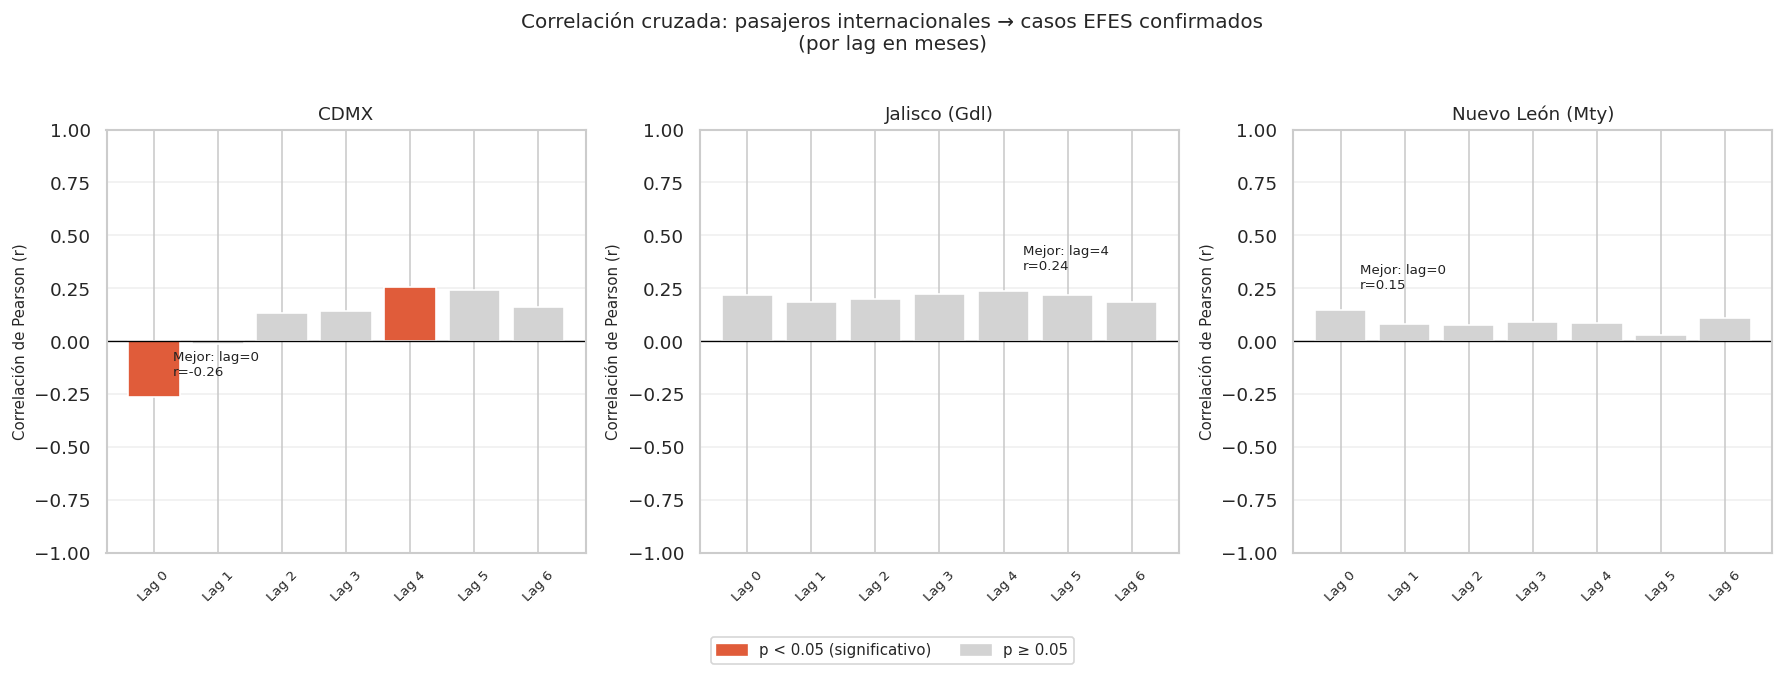


Resumen de mejor lag por sede:
  CDMX: lag=0 meses, r=-0.264
  Jalisco (Gdl): lag=4 meses, r=0.237
  Nuevo León (Mty): lag=0 meses, r=0.146


In [ ]:
LAGS = range(0, 7)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

lag_results = {}

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    col_casos = f'casos_confirmados_{nombre}'

    if col_casos not in panel.columns:
        print(f'Columna {col_casos} no encontrada — revisa el pivot')
        continue

    # Serie de casos y pasajeros en el overlap sin nulos
    df_lag = panel[['fecha', 'pasajeros_internacionales', col_casos]].dropna()

    correlaciones = []
    pvalores      = []

    for lag in LAGS:
        if lag == 0:
            x = df_lag['pasajeros_internacionales']
            y = df_lag[col_casos]
        else:
            x = df_lag['pasajeros_internacionales'].iloc[:-lag]
            y = df_lag[col_casos].iloc[lag:]

        r, p = stats.pearsonr(x, y)
        correlaciones.append(r)
        pvalores.append(p)

    lag_results[nombre] = {
        'correlaciones': correlaciones,
        'pvalores': pvalores,
        'mejor_lag': LAGS[np.argmax(np.abs(correlaciones))],
        'mejor_r': correlaciones[np.argmax(np.abs(correlaciones))]
    }

    # Barras de correlación por lag
    colors_bar = ['#e05c3a' if p < 0.05 else 'lightgray' for p in pvalores]
    ax.bar(list(LAGS), correlaciones, color=colors_bar, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(list(LAGS))
    ax.set_xticklabels([f'Lag {l}' for l in LAGS], rotation=45, fontsize=8)
    ax.set_ylabel('Correlación de Pearson (r)', fontsize=9)
    ax.set_title(f'{nombre}', fontsize=11)
    ax.set_ylim(-1, 1)
    ax.grid(axis='y', alpha=0.3)

    mejor = lag_results[nombre]
    ax.annotate(
        f'Mejor: lag={mejor["mejor_lag"]}\nr={mejor["mejor_r"]:.2f}',
        xy=(mejor['mejor_lag'], mejor['mejor_r']),
        xytext=(mejor['mejor_lag'] + 0.3, mejor['mejor_r'] + 0.1),
        fontsize=8, color='#222'
    )

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(color='#e05c3a', label='p < 0.05 (significativo)'),
        Patch(color='lightgray', label='p ≥ 0.05')
    ],
    loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.08)
)

plt.suptitle('Correlación cruzada: pasajeros internacionales → casos EFES confirmados\n(por lag en meses)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'correlacion_lag_pasajeros_casos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen de mejor lag por sede:')
for nombre, res in lag_results.items():
    print(f'  {nombre}: lag={res["mejor_lag"]} meses, r={res["mejor_r"]:.3f}')

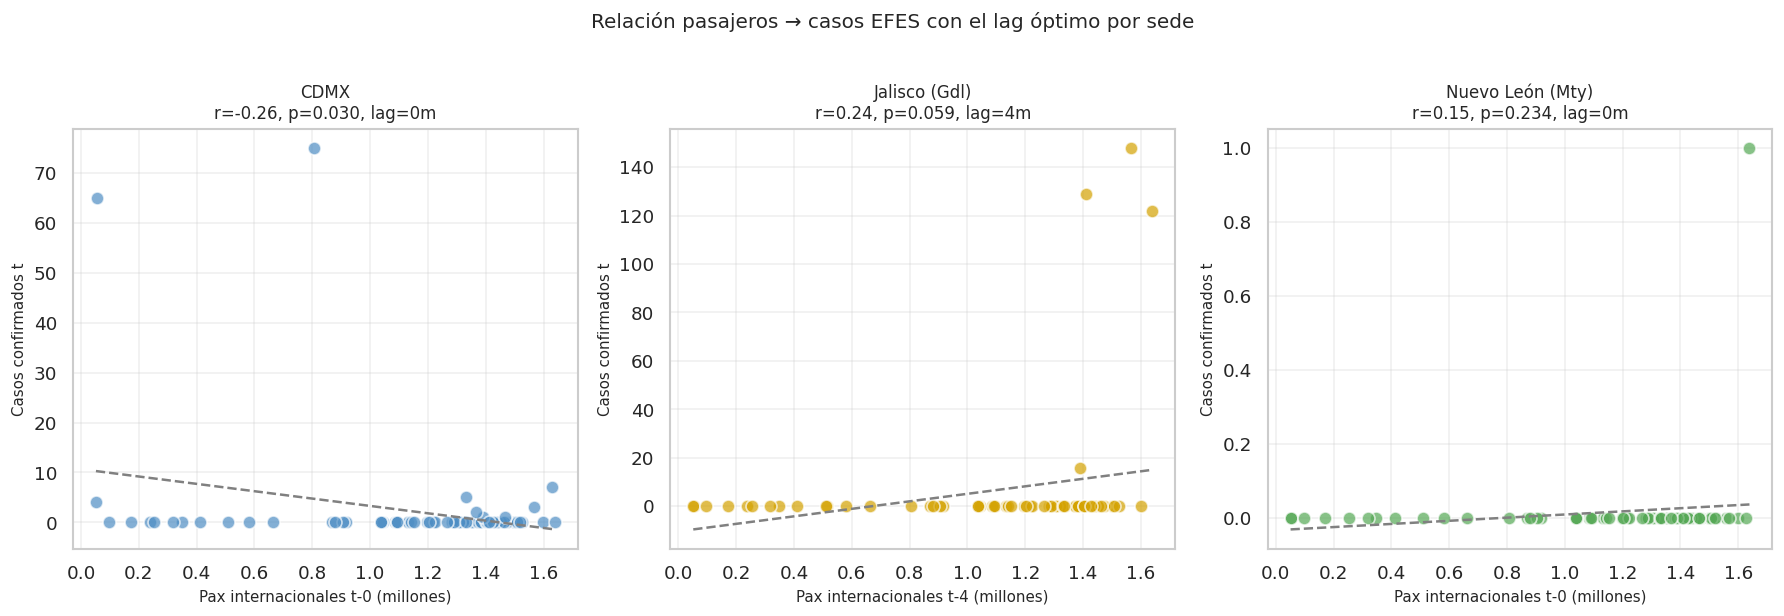

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    col_casos = f'casos_confirmados_{nombre}'
    if col_casos not in panel.columns:
        continue

    mejor_lag = lag_results[nombre]['mejor_lag']
    df_scatter = panel[['fecha', 'pasajeros_internacionales', col_casos]].dropna()

    if mejor_lag == 0:
        x = df_scatter['pasajeros_internacionales']
        y = df_scatter[col_casos]
        fechas = df_scatter['fecha']
    else:
        x = df_scatter['pasajeros_internacionales'].iloc[:-mejor_lag].values
        y = df_scatter[col_casos].iloc[mejor_lag:].values
        fechas = df_scatter['fecha'].iloc[mejor_lag:]

    ax.scatter(x / 1e6, y, color=COLORES[nombre], alpha=0.7, edgecolors='white', s=60)

    # Línea de tendencia
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line / 1e6, m * x_line + b, color='gray', linestyle='--', linewidth=1.5)

    ax.set_xlabel(f'Pax internacionales t-{mejor_lag} (millones)', fontsize=9)
    ax.set_ylabel(f'Casos confirmados t', fontsize=9)
    ax.set_title(f'{nombre}\nr={r:.2f}, p={p:.3f}, lag={mejor_lag}m', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Relación pasajeros → casos EFES con el lag óptimo por sede',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'scatter_lag_optimo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Visualización conjunta: pasajeros + casos + brotes detectados

Superponemos las tres series en un mismo gráfico para ver visualmente
si los picos de pasajeros preceden a los brotes.

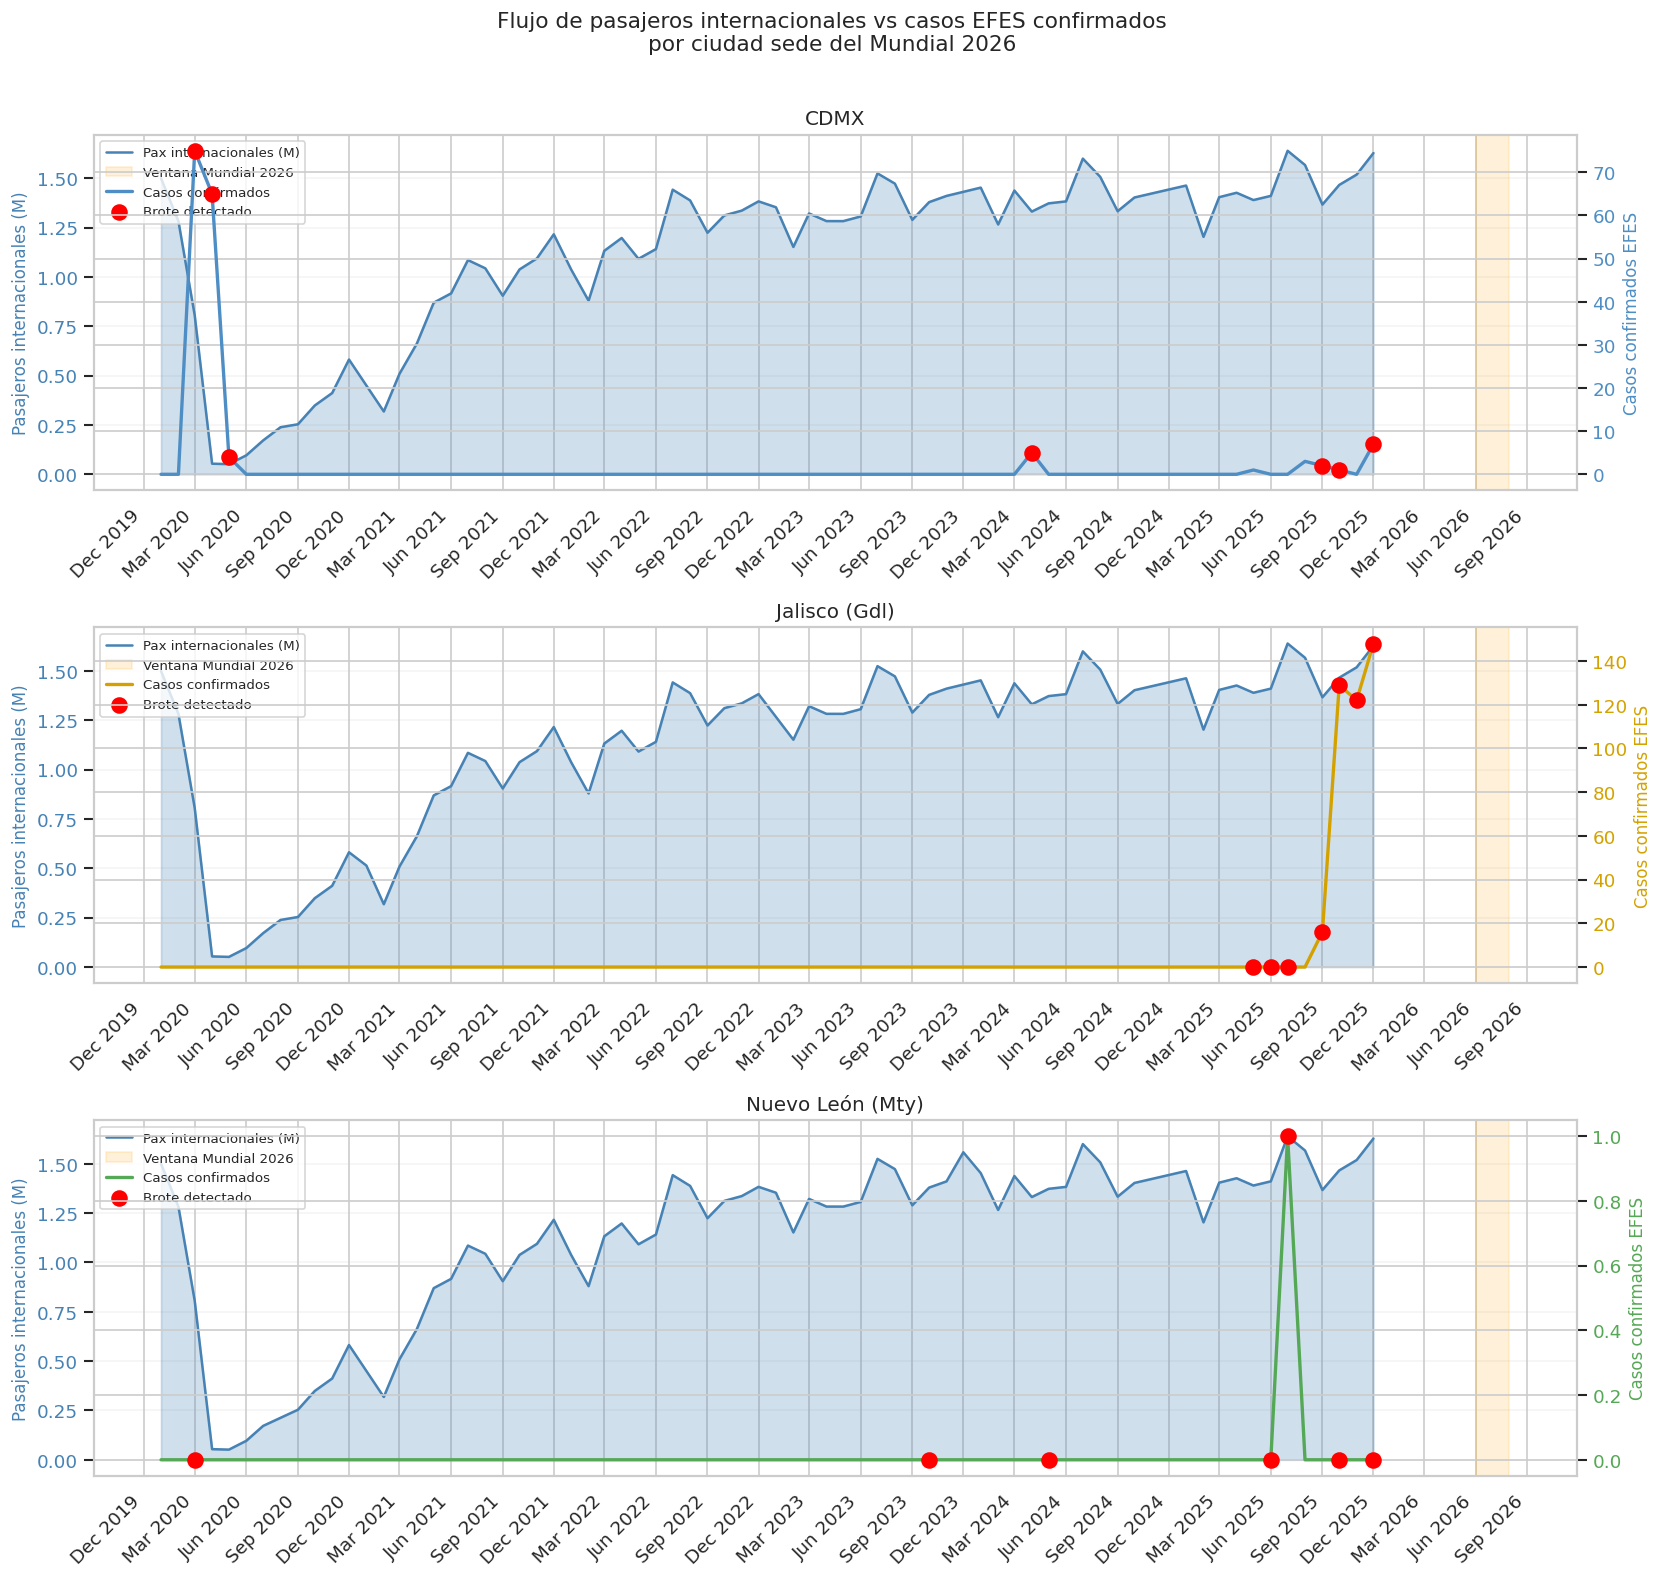

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)

for ax, (entidad, nombre) in zip(axes, SEDES.items()):
    col_casos  = f'casos_confirmados_{nombre}'
    col_brote  = f'brote_{nombre}'

    df_plot = panel[['fecha', 'pasajeros_internacionales', col_casos]].dropna().copy()

    # Eje izquierdo: pasajeros
    ax.fill_between(df_plot['fecha'],
                    df_plot['pasajeros_internacionales'] / 1e6,
                    alpha=0.25, color='steelblue')
    ax.plot(df_plot['fecha'],
            df_plot['pasajeros_internacionales'] / 1e6,
            color='steelblue', linewidth=1.5, label='Pax internacionales (M)')
    ax.set_ylabel('Pasajeros internacionales (M)', color='steelblue', fontsize=10)
    ax.tick_params(axis='y', labelcolor='steelblue')

    # Eje derecho: casos
    ax2 = ax.twinx()
    ax2.plot(df_plot['fecha'], df_plot[col_casos],
             color=COLORES[nombre], linewidth=2, label='Casos confirmados')
    ax2.set_ylabel('Casos confirmados EFES', color=COLORES[nombre], fontsize=10)
    ax2.tick_params(axis='y', labelcolor=COLORES[nombre])

    # Marcar brotes si la columna existe
    if col_brote in panel.columns:
        brotes = panel[panel[col_brote] == 1][['fecha']].merge(df_plot, on='fecha', how='inner')
        ax2.scatter(brotes['fecha'], brotes[col_casos],
                    color='red', s=80, zorder=5, label='Brote detectado')

    # Ventana Mundial
    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'),
               alpha=0.15, color='orange', label='Ventana Mundial 2026')

    ax.set_title(nombre, fontsize=12)
    ax.grid(axis='y', alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle('Flujo de pasajeros internacionales vs casos EFES confirmados\npor ciudad sede del Mundial 2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'pasajeros_vs_casos_dual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Proyección de riesgo para el Mundial 2026

Combinamos:
- El flujo histórico de pasajeros en junio-julio (estacionalidad AICM)
- El score de riesgo de los 9 equipos que juegan en México (Notebook 1)
- El lag óptimo encontrado en la sección 3
- Los partidos por sede (exposición directa)

para construir un **índice de riesgo proyectado** por ciudad sede y mes
del torneo.

In [ ]:
# Promedio histórico de pasajeros internacionales en jun-jul (pre-COVID y post-COVID)
aicm['anio']    = aicm['fecha'].dt.year
aicm['mes_num'] = aicm['fecha'].dt.month

jun_jul = aicm[aicm['mes_num'].isin([6, 7])].copy()

print('Pasajeros internacionales en junio-julio por año:')
print(
    jun_jul.groupby('anio')['pasajeros_internacionales']
    .sum()
    .apply(lambda x: f'{x/1e6:.2f}M')
    .to_string()
)

# Proyección 2026: usamos promedio 2022-2025 + factor Mundial
prom_post_covid = jun_jul[jun_jul['anio'].between(2022, 2025)]['pasajeros_internacionales'].mean()
factor_mundial  = 1.35   # estimación conservadora: +35% por el torneo
pax_proyectado  = prom_post_covid * factor_mundial

print(f'\nPromedio jun-jul 2022-2025: {prom_post_covid/1e6:.2f}M pax/mes')
print(f'Proyección jun-jul 2026 (+35% Mundial): {pax_proyectado/1e6:.2f}M pax/mes')
print('Nota: ajusta el factor_mundial según estimaciones oficiales FIFA/SECTUR.')

Pasajeros internacionales en junio-julio por año:
anio
2015    2.36M
2016    2.60M
2017    2.91M
2018    3.12M
2019    3.24M
2020    0.27M
2021    2.00M
2022    2.58M
2023    2.83M
2024    2.98M
2025    3.05M

Promedio jun-jul 2022-2025: 1.43M pax/mes
Proyección jun-jul 2026 (+35% Mundial): 1.93M pax/mes
Nota: ajusta el factor_mundial según estimaciones oficiales FIFA/SECTUR.


In [ ]:
# Partidos en México por sede (del Notebook 1)
partidos_por_sede = {
    'CDMX':             4,   # 3 grupo + 16vos + 8vos
    'Jalisco (Gdl)':    4,   # 3 grupo + 1 repechaje
    'Nuevo León (Mty)': 3,   # 3 grupo
}

# Score de riesgo promedio de los equipos que juegan en cada sede
score_por_sede = {}
for _, row in riesgo_paises.iterrows():
    # Mapear ciudad_sede a nombre de SEDES
    ciudad = row.get('ciudad_sede', None)
    if ciudad not in score_por_sede:
        score_por_sede[ciudad] = []
    score_por_sede[ciudad].append(row['score_riesgo_norm'])

score_por_sede = {k: np.mean(v) for k, v in score_por_sede.items() if k}

# Baseline histórico de casos en junio-julio por sede
baseline_casos = {}
for entidad, nombre in SEDES.items():
    col_casos = f'casos_confirmados_{nombre}'
    if col_casos in panel.columns:
        hist = panel[
            (panel['fecha'].dt.month.isin([6, 7])) &
            (panel['fecha'].dt.year.between(2022, 2025))
        ][col_casos].mean()
        baseline_casos[nombre] = hist

# Construir tabla de riesgo proyectado
riesgo_proyectado = []
for nombre_sede, nombre_key in [('CDMX','CDMX'),
                                  ('Guadalajara','Jalisco (Gdl)'),
                                  ('Monterrey','Nuevo León (Mty)')]:
    riesgo_proyectado.append({
        'ciudad':                nombre_key,
        'partidos_en_sede':      partidos_por_sede.get(nombre_key, 0),
        'score_riesgo_equipos':  score_por_sede.get(nombre_sede, score_prom),
        'pax_proyectado_M':      round(pax_proyectado / 1e6, 2),
        'baseline_casos_jun_jul': round(baseline_casos.get(nombre_key, 0), 1),
    })

df_riesgo = pd.DataFrame(riesgo_proyectado)

# Índice compuesto (normalizado 0-10)
df_riesgo['indice_riesgo'] = (
    df_riesgo['partidos_en_sede']        * 0.30 +
    df_riesgo['score_riesgo_equipos']    * 0.40 +
    df_riesgo['baseline_casos_jun_jul']  * 0.30
)
# Normalizar a 0-10
mn = df_riesgo['indice_riesgo'].min()
mx = df_riesgo['indice_riesgo'].max()
df_riesgo['indice_riesgo_norm'] = ((df_riesgo['indice_riesgo'] - mn) / (mx - mn) * 10).round(2)

print('Índice de riesgo proyectado por sede — Mundial 2026:')
print(df_riesgo.to_string(index=False))

Índice de riesgo proyectado por sede — Mundial 2026:
          ciudad  partidos_en_sede  score_riesgo_equipos  pax_proyectado_M  baseline_casos_jun_jul  indice_riesgo  indice_riesgo_norm
            CDMX                 4              2.655556              1.93                     0.0       2.262222                10.0
   Jalisco (Gdl)                 4              2.655556              1.93                     0.0       2.262222                10.0
Nuevo León (Mty)                 3              2.655556              1.93                     0.1       1.992222                 0.0


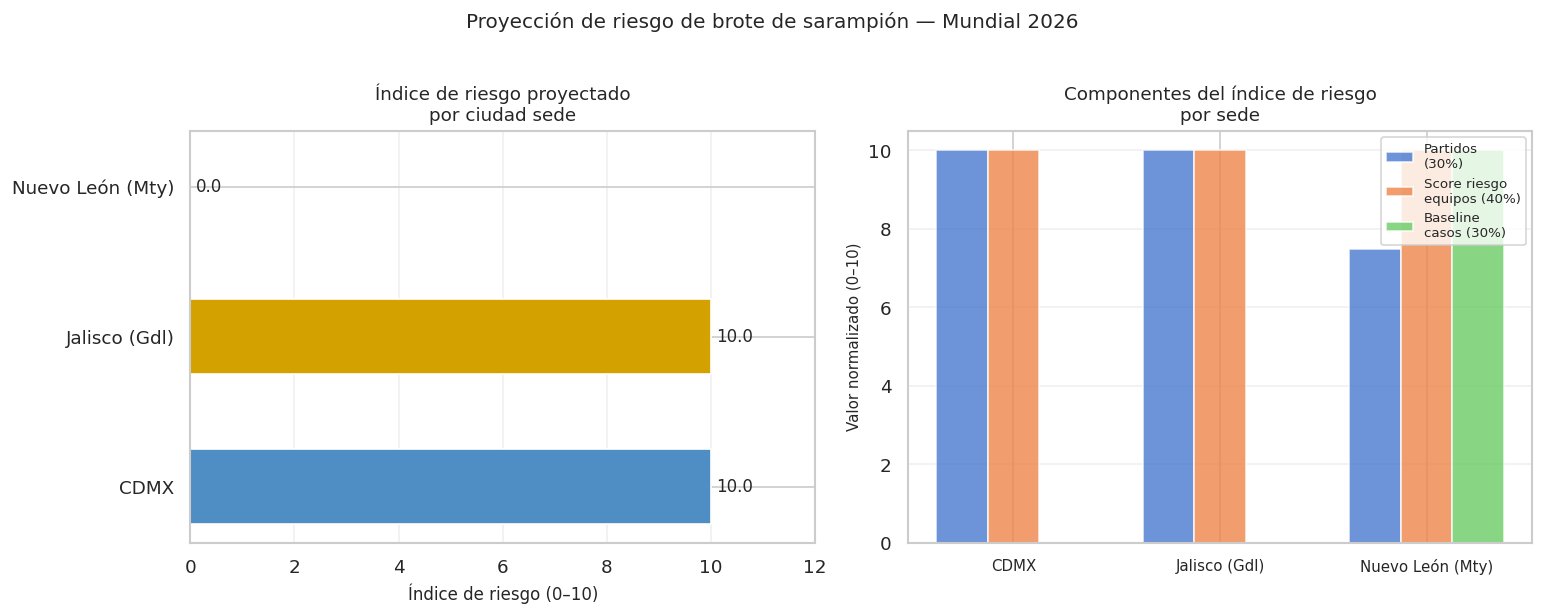

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: índice compuesto
ax = axes[0]
colors_riesgo = [COLORES[s] for s in df_riesgo['ciudad']]
bars = ax.barh(df_riesgo['ciudad'], df_riesgo['indice_riesgo_norm'],
               color=colors_riesgo, edgecolor='white', height=0.5)
for bar, val in zip(bars, df_riesgo['indice_riesgo_norm']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)
ax.set_xlabel('Índice de riesgo (0–10)', fontsize=10)
ax.set_title('Índice de riesgo proyectado\npor ciudad sede', fontsize=11)
ax.set_xlim(0, 12)
ax.grid(axis='x', alpha=0.3)

# Panel derecho: componentes del índice
ax = axes[1]
comp_cols = ['partidos_en_sede', 'score_riesgo_equipos', 'baseline_casos_jun_jul']
comp_labels = ['Partidos\n(30%)', 'Score riesgo\nequipos (40%)', 'Baseline\ncasos (30%)']

x = np.arange(len(df_riesgo))
width = 0.25

for i, (col, label) in enumerate(zip(comp_cols, comp_labels)):
    vals = df_riesgo[col] / df_riesgo[col].max() * 10   # normalizar a 0-10
    ax.bar(x + i*width, vals, width, label=label, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(df_riesgo['ciudad'], fontsize=9)
ax.set_ylabel('Valor normalizado (0–10)', fontsize=9)
ax.set_title('Componentes del índice de riesgo\npor sede', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Proyección de riesgo de brote de sarampión — Mundial 2026',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'indice_riesgo_proyectado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Construcción del dataset final para el modelo supervisado

Exportamos el panel mensual enriquecido con todas las features construidas
en los tres notebooks. Este es el input directo del modelo de clasificación.

In [ ]:
# Agregar features de lag con el mejor lag encontrado por sede
for entidad, nombre in SEDES.items():
    col_casos = f'casos_confirmados_{nombre}'
    if col_casos not in panel.columns:
        continue

    mejor_lag = lag_results.get(nombre, {}).get('mejor_lag', 1)

    panel[f'pax_intl_lag{mejor_lag}_{nombre}'] = (
        panel['pasajeros_internacionales'].shift(mejor_lag)
    )
    panel[f'vuelos_intl_lag{mejor_lag}_{nombre}'] = (
        panel['operaciones_vuelos_internacionales'].shift(mejor_lag)
    )

# Score de riesgo de países como feature constante
panel['score_riesgo_equipos_mexico'] = score_prom

# Guardar
panel.to_csv(DATA_PROCESSED + 'panel_mensual_completo.csv', index=False)

print(f'Dataset final exportado: panel_mensual_completo.csv')
print(f'Shape: {panel.shape}')
print(f'\nColumnas disponibles para el modelo supervisado:')
for col in sorted(panel.columns):
    nulos = panel[col].isna().sum()
    print(f'  {col:55s} nulos: {nulos}')

Dataset final exportado: panel_mensual_completo.csv
Shape: (70, 35)

Columnas disponibles para el modelo supervisado:
  brote_CDMX                                              nulos: 2
  brote_Jalisco (Gdl)                                     nulos: 2
  brote_Nuevo León (Mty)                                  nulos: 2
  brote_estricto_CDMX                                     nulos: 2
  brote_estricto_Jalisco (Gdl)                            nulos: 2
  brote_estricto_Nuevo León (Mty)                         nulos: 2
  casos_confirmados_CDMX                                  nulos: 2
  casos_confirmados_Jalisco (Gdl)                         nulos: 2
  casos_confirmados_Nuevo León (Mty)                      nulos: 2
  casos_sospechosos_CDMX                                  nulos: 2
  casos_sospechosos_Jalisco (Gdl)                         nulos: 2
  casos_sospechosos_Nuevo León (Mty)                      nulos: 2
  casos_who_mexico                                        nulos: 0
  fecha    

---
## 7. Conclusiones del Notebook 3

Responde estas preguntas después de correr el notebook:

1. **¿Existe correlación significativa (p < 0.05) entre pasajeros y casos?**
   ¿En qué lag? Un lag de 1-2 meses sería el escenario ideal para predicción.

2. **¿La correlación es positiva o negativa?**
   Se espera positiva: más pasajeros → más casos. Si es negativa, revisar
   si hay un efecto de dilución (más gente pero mejor vigilancia epidemiológica).

3. **¿Qué sede tiene el índice de riesgo más alto?**
   ¿Coincide con la que tiene más casos confirmados en 2026 (Jalisco)?

4. **¿El factor Mundial de +35% es razonable?**
   Compara con las estimaciones de SECTUR o FIFA de visitantes esperados.
   Ajusta `factor_mundial` según esa cifra.

5. **¿Qué features del panel resultan más prometedoras para el modelo?**
   Revisa las correlaciones y los lags — esas son las variables que
   el modelo supervisado deberá priorizar.

### Archivos generados
| Archivo | Uso |
|---|---|
| `panel_mensual_completo.csv` | Input del modelo supervisado (ETL final) |
| `indice_riesgo_proyectado.png` | Figura para el README del proyecto |
| `pasajeros_vs_casos_dual.png` | Evidencia de la hipótesis principal |
| `correlacion_lag_pasajeros_casos.png` | Justificación del lag como feature |

In [ ]:
print("=== LAG ÓPTIMO POR SEDE ===")
for nombre, res in lag_results.items():
    print(f"  {nombre}: lag={res['mejor_lag']} meses, r={res['mejor_r']:.3f}, p={res['pvalores'][res['mejor_lag']]:.3f}")

print("\n=== ÍNDICE DE RIESGO POR SEDE ===")
print(df_riesgo[['ciudad','partidos_en_sede','score_riesgo_equipos',
                  'baseline_casos_jun_jul','indice_riesgo_norm']].to_string(index=False))

print("\n=== PROYECCIÓN PASAJEROS ===")
print(f"Promedio jun-jul 2022-2025: {prom_post_covid/1e6:.2f}M pax/mes")
print(f"Proyección jun-jul 2026 (+35%): {pax_proyectado/1e6:.2f}M pax/mes")

print("\n=== PANEL FINAL ===")
print(f"Shape: {panel.shape}")
print(f"Rango: {panel['fecha'].min().date()} → {panel['fecha'].max().date()}")
print(f"Nulos por columna:")
print(panel.isnull().sum()[panel.isnull().sum() > 0].to_string())

=== LAG ÓPTIMO POR SEDE ===
  CDMX: lag=0 meses, r=-0.264, p=0.030
  Jalisco (Gdl): lag=4 meses, r=0.237, p=0.059
  Nuevo León (Mty): lag=0 meses, r=0.146, p=0.234

=== ÍNDICE DE RIESGO POR SEDE ===
          ciudad  partidos_en_sede  score_riesgo_equipos  baseline_casos_jun_jul  indice_riesgo_norm
            CDMX                 4              2.655556                     0.0                10.0
   Jalisco (Gdl)                 4              2.655556                     0.0                10.0
Nuevo León (Mty)                 3              2.655556                     0.1                 0.0

=== PROYECCIÓN PASAJEROS ===
Promedio jun-jul 2022-2025: 1.43M pax/mes
Proyección jun-jul 2026 (+35%): 1.93M pax/mes

=== PANEL FINAL ===
Shape: (70, 35)
Rango: 2020-01-01 → 2025-12-01
Nulos por columna:
brote_CDMX                            2
brote_Jalisco (Gdl)                   2
brote_Nuevo León (Mty)                2
brote_estricto_CDMX                   2
brote_estricto_Jalisco (Gdl)    